In [1]:
import torch
import torch.nn as nn
import numpy as np
from models import CondRealNVP2d, CondRealNVP

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
from pathlib import Path

num_batches = 100

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data/data_uni_nf/')

coord_list = []
current_list = []
voltage_list = []
input_idx = 0

for i in range(num_batches):
    fp = data_dir / f'dataset_batch_{i:04d}.pt'
    data = torch.load(fp, weights_only=False, map_location='cpu')
    coord_list.append(data['X'])
    current_list.append(data['y'])
    voltage_list.append(data['V'][..., input_idx].reshape(-1, 1))

coord_set = np.concatenate(coord_list)
current_set = np.concatenate(current_list)
voltage_set = np.concatenate(voltage_list)

print('Dataset loaded')

Dataset loaded


In [3]:
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data import random_split
from train_sm import MakeDataset

train_size = 0.8
val_size = 0.1
test_size = 0.1

X = torch.from_numpy(coord_set).float()
C = torch.from_numpy(np.concatenate([voltage_set, current_set.reshape(-1, 1)], axis=1)).float()
print(X.shape)
print(C.shape)
num_points = 200
X_flat = X.reshape(-1, 2)
C_flat = C.repeat_interleave(num_points, dim=0)

perm = torch.randperm(X_flat.size(0))

X_flat = X_flat[perm]
C_flat = C_flat[perm]

print(X_flat.shape)
print(C_flat.shape)

#dataset = TensorDataset(X_flat, C_flat)
small_N = 5_000_000
dataset = TensorDataset(X_flat[:small_N], C_flat[:small_N])

generator_1 = torch.Generator().manual_seed(43)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

batch_size = 4096*2
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)

print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))
print('Dataloaders ready')

torch.Size([100000, 200, 2])
torch.Size([100000, 2])
torch.Size([20000000, 2])
torch.Size([20000000, 2])
4000000
500000
500000
Dataloaders ready


In [4]:
from tqdm import tqdm

model = CondRealNVP(x_dim=2, cond_dim=2, num_coupling_layers=5, h_dim=64)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 50

train_losses = []
val_losses = []
with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        model.train()
        train_loss = 0.0
        n_train = 0
        for x, c in train_loader:
            x = x.to(device)          # (batch, 2)
            c = c.to(device)          # (batch, cond_dim)
    
            log_prob = model.log_prob(x, c)   # (batch,)
            loss = -log_prob.mean()
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            n_train += batch_size

        train_loss /= n_train
        train_losses.append(train_loss)
    
        model.eval()
        val_loss = 0.0
        n_val = 0
    
        with torch.no_grad():
            for x_val, c_val in val_loader:
                x_val = x_val.to(device)
                c_val = c_val.to(device)
    
                log_prob_val = model.log_prob(x_val, c_val)
                loss_val = -log_prob_val.mean()
    
                batch_size = x_val.size(0)
                val_loss += loss_val.item() * batch_size
                n_val += batch_size
    
        val_loss /= n_val
        val_losses.append(val_loss)
    
        pbar.set_postfix({
            "Epoch": f"{epoch:03d}",
            "train NLL": f"{train_loss:.4f}",
            "val NLL": f"{val_loss:.4f}"
        })
        pbar.update(1)

Epochs: 100%|██████████| 50/50 [09:21<00:00, 11.24s/it, Epoch=050, train NLL=1.1554, val NLL=1.1555]


Test NLL: 1.1557


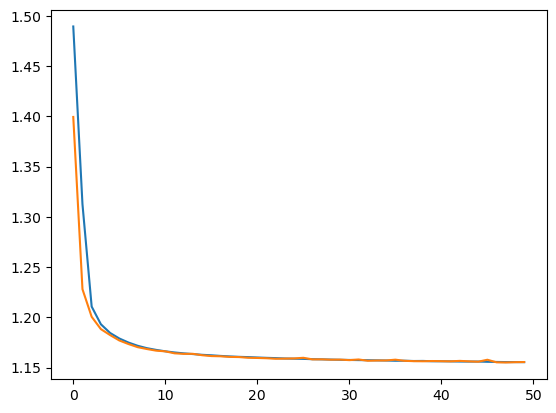

In [45]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.plot(val_losses)
#print(train_losses)
#print(val_losses)

model.eval()

test_nll = 0.0
total_n = 0

with torch.no_grad():
    for x, c in test_loader:
        x = x.to(device)
        c = c.to(device)

        log_prob = model.log_prob(x, c)
        loss = -log_prob.mean()

        batch_size = x.size(0)
        test_nll += loss * batch_size
        total_n += batch_size

print(f'Test NLL: {test_nll / total_n:.4f}')

torch.save(model.state_dict(), f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/nf_iid_uni.pth')

In [1]:
def sample_cfg(model, c_single, num_samples=200, device=device):

    model.eval()

    with torch.no_grad():
        c_batch = c_single.unsqueeze(0).expand(num_samples, -1).to(device)
        z = torch.randn(num_samples, 2, device=device)

        x, _ = model.inverse(z, c_batch)
    
    return x.detach().cpu().numpy()

def plot_2d_heatmap(points, title="Heatmap", R=None, bins=100):
    """
    points: (N, 2) torch tensor or numpy array
    R: disc radius to plot, if None it uses min/max from data
    bins: number of bins in each dimension
    """

    import matplotlib.patches as ps
        
    if isinstance(points, torch.Tensor):
        points = points.cpu().numpy()

    x = points[:, 0]
    y = points[:, 1]

    pad = 0.05*R
    
    if R is not None:
        # fixed range for comparability
        range_ = [[-R-pad, R+pad], [-R-pad, R+pad]]
    else:
        # use data range
        range_ = [[x.min(), x.max()], [y.min(), y.max()]]

    fig, ax = plt.subplots()
    H , xedges, yedges, im = ax.hist2d(x, y, bins=bins, range=range_, cmap='magma')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('counts')
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    ax.add_patch(ps.Circle(xy=(0,0), radius=R, fill=None, color='w', zorder=6))

print(current_set.min(), current_set.max())

c_single = torch.tensor([-1.5, 1.0], dtype=torch.float32)
x = sample_cfg(model, c_single, num_samples=100_000)

plot_2d_heatmap(x, R=1.0)

#fig, ax = plt.subplots()
#ax.scatter(*x.T)

NameError: name 'device' is not defined